# 1. IMPORT LIBRARIES

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


# 2. LOAD FASHION-MNIST DATASET

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()


# Original shape:
# (60000, 28, 28)

print("Original shape:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original shape: (60000, 28, 28)


# 3. NORMALIZE IMAGES

In [3]:
# Convert uint8 -> float32
# Convert pixel range:
#
# 0   -> -1
# 127.5 -> 0
# 255 -> +1
#
# This matches the Generator's tanh output.

x_train = (x_train.astype("float32") - 127.5) / 127.5

# 4. ADD CHANNEL DIMENSION

In [4]:
# Before:
# (60000, 28, 28)
#
# After:
# (60000, 28, 28, 1)
#
# 1 = grayscale channel

x_train = np.expand_dims(x_train, axis=-1)

print("After adding channel:", x_train.shape)


After adding channel: (60000, 28, 28, 1)


# 5. CREATE TF.DATA DATASET

In [5]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

# 6. LATENT VECTOR SIZE

In [6]:
LATENT_DIM = 100


# 7. BUILD GENERATOR

In [7]:
def build_generator():

    model = tf.keras.Sequential()

    # --------------------------------------------------------
    # Input:
    # 100 random numbers
    #
    # Output:
    # 7 * 7 * 256 = 12544 numbers
    # --------------------------------------------------------

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(LATENT_DIM,)
        )
    )

    # Normalize activations
    model.add(layers.BatchNormalization())

    # Activation function
    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )

    # --------------------------------------------------------
    # Convert vector into feature maps
    #
    # 12544
    #   ↓
    # 7 × 7 × 256
    # --------------------------------------------------------

    model.add(
        layers.Reshape((7, 7, 256))
    )

    # --------------------------------------------------------
    # 7 × 7 × 256
    #      ↓
    # 7 × 7 × 128
    #
    # stride = 1 means spatial size remains 7 × 7
    # --------------------------------------------------------

    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())

    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )

    # --------------------------------------------------------
    # 7 × 7 × 128
    #      ↓
    # 14 × 14 × 64
    #
    # stride = 2 doubles height and width
    # --------------------------------------------------------

    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())

    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )

    # --------------------------------------------------------
    # 14 × 14 × 64
    #      ↓
    # 28 × 28 × 1
    #
    # Final image
    # --------------------------------------------------------

    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model


# Create Generator
generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

# 8. BUILD DISCRIMINATOR

In [8]:
def build_discriminator():

    model = tf.keras.Sequential()

    # --------------------------------------------------------
    # Input:
    # 28 × 28 × 1
    # --------------------------------------------------------

    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=[28, 28, 1]
        )
    )

    # 28 × 28 × 1
    #      ↓
    # 14 × 14 × 64

    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )

    model.add(
        layers.Dropout(0.3)
    )

    # --------------------------------------------------------
    # 14 × 14 × 64
    #      ↓
    # 7 × 7 × 128
    # --------------------------------------------------------

    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(
        layers.LeakyReLU(negative_slope=0.2)
    )

    model.add(
        layers.Dropout(0.3)
    )

    # --------------------------------------------------------
    # 7 × 7 × 128
    #      ↓
    # Flatten
    #      ↓
    # 6272 numbers
    # --------------------------------------------------------

    model.add(
        layers.Flatten()
    )

    # --------------------------------------------------------
    # 6272
    #   ↓
    # 1 number
    #
    # No sigmoid here because we use:
    # BinaryCrossentropy(from_logits=True)
    # --------------------------------------------------------

    model.add(
        layers.Dense(1)
    )

    return model


# Create Discriminator
discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# 9. LOSS FUNCTION

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)


# 10. DISCRIMINATOR LOSS

In [10]:
def discriminator_loss(real_output, fake_output):

    # Real images should produce 1
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    # Fake images should produce 0
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    # Total discriminator loss
    return real_loss + fake_loss


# 11. GENERATOR LOSS

In [11]:
def generator_loss(fake_output):

    # Generator wants discriminator
    # to classify fake images as REAL (1)

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

# 12. OPTIMIZERS

In [12]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)


# 13. ONE TRAINING STEP

In [13]:
@tf.function
def train_step(images):

    # Get the number of real images in this batch
    batch_size = tf.shape(images)[0]

    # --------------------------------------------------------
    # Generate random noise
    #
    # Example:
    # 128 × 100
    # --------------------------------------------------------

    noise = tf.random.normal(
        [batch_size, LATENT_DIM]
    )


    # --------------------------------------------------------
    # Two GradientTapes:
    #
    # gen_tape  -> Generator gradients
    # disc_tape -> Discriminator gradients
    # --------------------------------------------------------

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # ----------------------------------------------------
        # Generator creates fake images
        #
        # 128 × 100
        #       ↓
        # Generator
        #       ↓
        # 128 × 28 × 28 × 1
        # ----------------------------------------------------

        generated_images = generator(
            noise,
            training=True
        )


        # ----------------------------------------------------
        # Discriminator looks at REAL images
        # ----------------------------------------------------

        real_output = discriminator(
            images,
            training=True
        )


        # ----------------------------------------------------
        # Discriminator looks at FAKE images
        # ----------------------------------------------------

        fake_output = discriminator(
            generated_images,
            training=True
        )


        # ----------------------------------------------------
        # Calculate losses
        # ----------------------------------------------------

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )


    # ========================================================
    # CALCULATE GRADIENTS
    # ========================================================

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )


    # ========================================================
    # UPDATE GENERATOR
    # ========================================================

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )


    # ========================================================
    # UPDATE DISCRIMINATOR
    # ========================================================

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )


    return gen_loss, disc_loss


# 14. TRAINING

In [14]:
EPOCHS = 25

for epoch in range(EPOCHS):

    for image_batch in train_dataset:

        g_loss, d_loss = train_step(image_batch)

    # Print once per epoch rather than once per batch
    print(
        f"Epoch {epoch + 1}/{EPOCHS}, "
        f"Generator Loss: {g_loss:.4f}, "
        f"Discriminator Loss: {d_loss:.4f}"
    )


Epoch 1/25, Generator Loss: 0.6911, Discriminator Loss: 1.3415
Epoch 2/25, Generator Loss: 0.8960, Discriminator Loss: 1.2505
Epoch 3/25, Generator Loss: 0.9346, Discriminator Loss: 1.2132
Epoch 4/25, Generator Loss: 0.7310, Discriminator Loss: 1.2816
Epoch 5/25, Generator Loss: 0.7445, Discriminator Loss: 1.2764
Epoch 6/25, Generator Loss: 0.7552, Discriminator Loss: 1.3462
Epoch 7/25, Generator Loss: 0.8295, Discriminator Loss: 1.2766
Epoch 8/25, Generator Loss: 0.9423, Discriminator Loss: 1.3331
Epoch 9/25, Generator Loss: 0.7813, Discriminator Loss: 1.3693
Epoch 10/25, Generator Loss: 0.7962, Discriminator Loss: 1.3565
Epoch 11/25, Generator Loss: 0.6819, Discriminator Loss: 1.3320
Epoch 12/25, Generator Loss: 0.6169, Discriminator Loss: 1.3469
Epoch 13/25, Generator Loss: 0.8247, Discriminator Loss: 1.3274
Epoch 14/25, Generator Loss: 0.8809, Discriminator Loss: 1.3455
Epoch 15/25, Generator Loss: 0.8029, Discriminator Loss: 1.3600
Epoch 16/25, Generator Loss: 0.8279, Discriminato

# 15. GENERATE IMAGES AFTER TRAINING

In [15]:
# Generate 16 random latent vectors
noise = tf.random.normal(
    [16, LATENT_DIM]
)


# Send them through Generator
generated_images = generator(
    noise,
    training=False
)


# Convert TensorFlow tensor to NumPy array
generated_images = generated_images.numpy()

# 16. CONVERT PIXEL RANGE

In [16]:
# Generator output:
# [-1, 1]
#
# Display range:
# [0, 1]

generated_images = (
    generated_images + 1
) / 2


# 17. DISPLAY GENERATED IMAGES

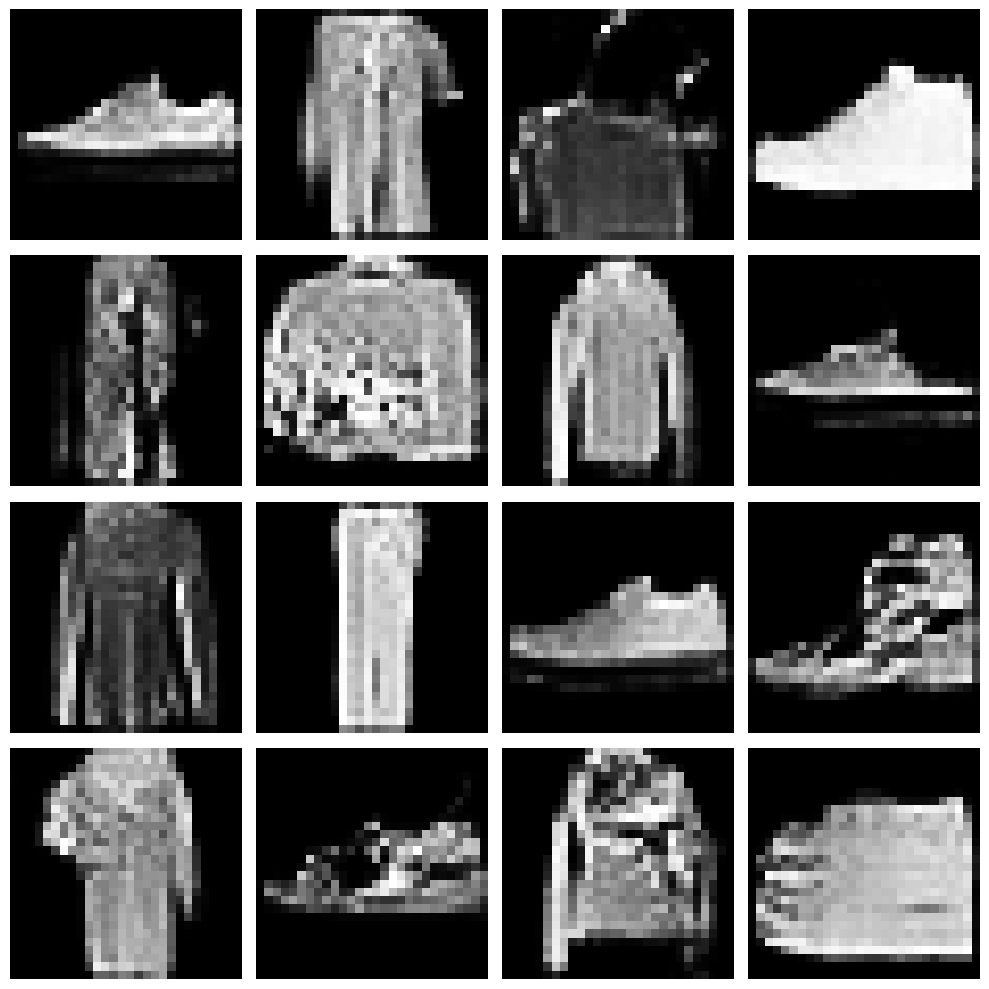

In [17]:
plt.figure(figsize=(10, 10))


# IMPORTANT:
# range(16), not range(4,4,i+1)

for i in range(16):

    plt.subplot(4, 4, i + 1)

    # generated_images shape:
    #
    # 16 × 28 × 28 × 1
    #
    # [:, :, 0] removes the channel dimension
    #
    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()